In [88]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "visualization" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from ppm.wandb_utils import load_multiple_experiments

plots_dir = PROJECT_ROOT / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [89]:
PROJECTS_SCRATCH = [
    "BPI19_lrz_nanogpt_scratch_new_001",
    "BPI17_lrz_nanogpt_scratch_new_001",
    "BPI15_lrz_nanogpt_scratch_new_001",
    "BPI12_lrz_nanogpt_scratch_new_001",
]

PROJECTS_DISTILL = [
    "BPI19_lrz_distill_fixed_001",
    "BPI15_lrz_distill_fixed_001",
    "BPI17_lrz_distill_fixed_001",
    "BPI12_lrz_distill_fixed_001",
    "BPI20TPD_lrz_distill_fixed_001",
    "BPI20RFP_lrz_distill_fixed_001",
    "BPI20PTC_lrz_distill_fixed_001",
]

PROJECTS_FINETUNE = [
    "BPI12_lrz_001_003",
    "BPI19_lrz_002_002",
    "BPI17_lrz_002_002",
    "BPI15_lrz_002_001",
    "BPI17_spark_002_002",
    "BPI20_lrz_002_002",
    "BPI17_spark_002_001",
    "BPI12_spark_002_003",
    "BPI20_RFP_lrz_002",
    "BPI12_spark_002_002",
    "BPI20_PTC_lrz_002",
    "BPI19_lrz_002",
    "BPI15_lrz_002",
    "BPI12_spark_002",
    "BPI20_TPD_spark_001",
    "BPI17_lrz_002",
    "BPI20_PTC_spark_001",
    "BPI19_lrz_001",
    "BPI15_lrz_001",
    "BPI20_TPD_lrz_001",
    "BPI20_RFP_lrz_001",
    "BPI20_PTC_lrz_001",
    "lstm_bpi12_size100_layers3_001",
    "BPI17_lrz_001",
    "BPI12_lrz_001",
]

INCLUDE_BASELINE = True
PROJECTS = PROJECTS_SCRATCH + PROJECTS_DISTILL + PROJECTS_FINETUNE
if INCLUDE_BASELINE and "baseline-nep" not in PROJECTS:
    PROJECTS.append("baseline-nep")

runs_raw, _ = load_multiple_experiments(PROJECTS, force_update=False)


Database already exists: /app/visualization/metrics/BPI19_lrz_nanogpt_scratch_new_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI17_lrz_nanogpt_scratch_new_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI15_lrz_nanogpt_scratch_new_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI12_lrz_nanogpt_scratch_new_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI19_lrz_distill_fixed_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI15_lrz_distill_fixed_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI17_lrz_distill_fixed_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/metrics/BPI12_lrz_distill_fixed_001.

In [90]:
runs_all = runs_raw.copy()
runs_all["best_test_final_next_activity_f1"] = (
    runs_all["best_test_final_next_activity_f1"]
    .combine_first(runs_all["best_test_final_next_activity_f1_macro"])
)
runs_all = runs_all.drop(columns=["best_test_final_next_activity_f1_macro"], errors="ignore")

for col in ["hidden_size", "n_layers", "n_heads"]:
    if col in runs_all.columns:
        runs_all[col] = pd.to_numeric(runs_all[col], errors="coerce")

def _fmt_int(v):
    return str(int(v)) if pd.notna(v) else "nan"

def _arch_label(df: pd.DataFrame) -> pd.Series:
    return (
        df["hidden_size"].map(_fmt_int)
        + "_"
        + df["n_layers"].map(_fmt_int)
        + "_"
        + df["n_heads"].map(_fmt_int)
    )

# Keep internal backbone distinct per source for separate aggregation,
# but display as <hidden>_<layers>_<heads> in plots/tables.
scratch_mask = runs_all["project"].astype(str).str.contains("nanogpt_scratch", na=False)
runs_all.loc[scratch_mask, "backbone"] = "scratch_" + _arch_label(runs_all.loc[scratch_mask])

distill_mask = runs_all["project"].astype(str).str.contains("distill", na=False)
runs_all.loc[distill_mask, "backbone"] = "distill_" + _arch_label(runs_all.loc[distill_mask])


def select_project_view(df: pd.DataFrame, view="all", include_baseline: bool = True) -> pd.DataFrame:
    proj = df["project"].astype(str)
    is_scratch = proj.str.contains("nanogpt_scratch", na=False)
    is_distill = proj.str.contains("distill", na=False)
    is_baseline = proj.eq("baseline-nep")
    is_finetune = proj.isin(PROJECTS_FINETUNE)

    source_masks = {
        "scratch": is_scratch,
        "distill": is_distill,
        "finetune": is_finetune,
    }

    if isinstance(view, (list, tuple, set)):
        selected = {str(v).strip().lower() for v in view if str(v).strip()}
    else:
        v = str(view).strip().lower()
        if v in {"all", "both+finetune", "scratch+distill+finetune"}:
            selected = {"scratch", "distill", "finetune"}
        elif v == "both":
            selected = {"scratch", "distill"}
        else:
            selected = {p.strip() for p in v.replace("+", ",").split(",") if p.strip()}

    invalid = selected - set(source_masks)
    if invalid:
        raise ValueError(
            "view must be one or a combination of: 'scratch', 'distill', 'finetune', 'both', 'all'"
        )

    mask = pd.Series(False, index=df.index)
    for src in selected:
        mask = mask | source_masks[src]

    if include_baseline:
        mask = mask | is_baseline

    return df.loc[mask].copy()


# Change these two values and re-run this cell + downstream graph/list cells.
PROJECT_VIEW = "all"  # e.g. "scratch", "distill", "finetune", "both", "all", "scratch+finetune"
INCLUDE_BASELINE_IN_VIEW = True

runs = select_project_view(runs_all, view=PROJECT_VIEW, include_baseline=INCLUDE_BASELINE_IN_VIEW)
print(f"PROJECT_VIEW={PROJECT_VIEW} | INCLUDE_BASELINE_IN_VIEW={INCLUDE_BASELINE_IN_VIEW} | runs={len(runs)}")


PROJECT_VIEW=all | INCLUDE_BASELINE_IN_VIEW=True | runs=1231


## Print overview experiments
### -> Metric can be from ["best_test_final_next_activity_f1", "best_test_final_next_activity_acc"]

In [91]:
#METRIC = "best_test_final_next_activity_acc"
METRIC = "best_test_final_next_activity_f1"

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]  # only keep ones that exist

# Build df with everything we need
df = runs[GROUP_COLS + ["id", METRIC] + EXTRA_COLS].dropna(subset=[METRIC]).copy()
df[METRIC] = df[METRIC].astype(float)

# 1) Metric stats (ONLY from METRIC)
agg = (
    df.groupby(GROUP_COLS)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean": "acc_mean",
          "std": "acc_std",
          "min": "acc_min",
          "max": "acc_max",
      })
)

# 2) Add “descriptor” columns (not metric-related)
#    We assume these are constant within group; if not, we’ll detect it below.
descriptors = df.groupby(GROUP_COLS)[EXTRA_COLS].first() if EXTRA_COLS else None

# Optional: detect groups where descriptors are NOT constant
if EXTRA_COLS:
    nunique = df.groupby(GROUP_COLS)[EXTRA_COLS].nunique(dropna=False)
    bad = (nunique > 1).any(axis=1)
    if bad.any():
        print("Warning: some groups have varying descriptor values:")
        display(nunique[bad].reset_index())

# 3) Best run id per group (based on METRIC)
best_idx = df.groupby(GROUP_COLS)[METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# 4) Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)

summary = summary.join(best_runs).reset_index()
summary["n_runs"] = summary["n_runs"].astype(int)

for col in ["acc_mean", "acc_std", "acc_min", "acc_max"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,lr,batch_size,categorical_features,continuous_features,project,total_params,trainable_params,embedding_size
0,BPI12,gpt2,0.00500,64.0,['activity'],['accumulated_time'],3,1,1,2
1,BPI12,gpt2-mini,0.00500,64.0,['activity'],['accumulated_time'],1,1,1,2
2,BPI12,qwen3-0.6b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
3,BPI12,qwen3-0.6b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1
4,BPI12,qwen3-0.6b,0.00500,64.0,['activity'],['accumulated_time'],2,1,1,1
5,BPI12,qwen3-1.7b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
6,BPI12,qwen3-1.7b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1
7,BPI12,qwen3-1.7b,0.00500,64.0,['activity'],['accumulated_time'],2,1,1,1
8,BPI12,qwen3-4b,0.00005,64.0,['activity'],['accumulated_time'],2,1,1,1
9,BPI12,qwen3-4b,0.00050,64.0,['activity'],['accumulated_time'],2,1,1,1


,log,backbone,lr,batch_size,categorical_features,continuous_features,n_runs,acc_mean,acc_std,acc_min,acc_max,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,distill_128_6_2,0.00500,64.0,['activity'],['accumulated_time'],5,0.6724,0.0113,0.6603,0.6838,BPI12_lrz_distill_fixed_001,1.332391e+06,1332391.0,NaN,jw7igsob
1,BPI12,distill_256_6_4,0.00500,64.0,['activity'],['accumulated_time'],5,0.6725,0.0117,0.6635,0.6858,BPI12_lrz_distill_fixed_001,5.024039e+06,5024039.0,NaN,r34fp8v3
2,BPI12,distill_512_12_8,0.00500,64.0,['activity'],['accumulated_time'],5,0.6773,0.0078,0.6651,0.6867,BPI12_lrz_distill_fixed_001,3.839953e+07,38399527.0,NaN,n874h7r2
3,BPI12,distill_512_6_8,0.00500,64.0,['activity'],['accumulated_time'],5,0.6626,0.0355,0.6008,0.6869,BPI12_lrz_distill_fixed_001,1.948522e+07,19485223.0,NaN,gj12qbvt
4,BPI12,distill_64_3_1,0.00500,64.0,['activity'],['accumulated_time'],5,0.6752,0.0057,0.6689,0.6811,BPI12_lrz_distill_fixed_001,2.213510e+05,221351.0,NaN,9g77td9j
5,BPI12,distill_64_6_1,0.00500,64.0,['activity'],['accumulated_time'],5,0.6776,0.0040,0.6733,0.6829,BPI12_lrz_distill_fixed_001,3.713030e+05,371303.0,NaN,hv8myqd2
6,BPI12,distill_768_12_12,0.00500,64.0,['activity'],['accumulated_time'],5,0.6591,0.0453,0.5816,0.6922,BPI12_lrz_distill_fixed_001,8.591082e+07,85910823.0,NaN,50yci2av
7,BPI12,gpt2,0.00005,64.0,['activity'],['accumulated_time'],8,0.5343,0.0277,0.4836,0.5715,BPI12_lrz_001,1.245044e+08,64551.0,NaN,c947ecdg
8,BPI12,gpt2,0.00050,64.0,['activity'],['accumulated_time'],5,0.6338,0.0360,0.5776,0.6666,BPI12_lrz_001,1.245044e+08,64551.0,NaN,jyb5k3cq
9,BPI12,gpt2,0.00500,64.0,['activity'],['accumulated_time'],25,0.6674,0.0154,0.6381,0.7029,BPI12_lrz_001_003,1.245044e+08,64551.0,768.0,dp0zs0q6


In [92]:
import json
import pandas as pd

METRICS = {
    "best_test_final_next_activity_acc": "acc",
    "best_test_final_next_activity_f1": "f1",
}

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]

def make_hashable(x):
    """Convert unhashable objects (list/dict/set) into a stable string for grouping."""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (list, tuple)):
        return json.dumps(x, sort_keys=True)
    if isinstance(x, set):
        return json.dumps(sorted(list(x)))
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True)
    return x  # already hashable (str/int/float/etc.)

tmp = runs.copy()

# Ensure ALL grouping columns are hashable
for c in GROUP_COLS:
    if c in tmp.columns:
        tmp[c] = tmp[c].map(make_hashable)

# Build df
df = tmp[GROUP_COLS + ["id"] + list(METRICS.keys()) + EXTRA_COLS].copy()

# metrics numeric
for m in METRICS:
    df[m] = pd.to_numeric(df[m], errors="coerce")

# keep rows with at least one metric
df = df.dropna(subset=list(METRICS.keys()), how="all")

# Aggregate count + mean (KEEP NaN groups)
agg = (
    df.groupby(GROUP_COLS, dropna=False)
      .agg({m: ["count", "mean"] for m in METRICS})
)

# Flatten columns
agg.columns = [
    f"{METRICS[m]}_n_runs" if stat == "count" else f"{METRICS[m]}_mean"
    for (m, stat) in agg.columns
]

# Descriptors (KEEP NaN groups)
descriptors = (
    df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].first()
    if EXTRA_COLS else None
)

# Best run id (choose priority metric)
BEST_METRIC = "best_test_final_next_activity_acc"
best_idx = df.groupby(GROUP_COLS, dropna=False)[BEST_METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)
summary = summary.join(best_runs).reset_index()

# Display: show missing config as '-'
DISPLAY_COLS = GROUP_COLS + EXTRA_COLS
for c in DISPLAY_COLS:
    if c in summary.columns:
        summary[c] = summary[c].astype("object").where(summary[c].notna(), "-")

# Format means
for col in ["acc_mean", "f1_mean"]:
    if col in summary.columns:
        summary[col] = summary[col].map(lambda x: "-" if pd.isna(x) else f"{x:.4f}")

# Counts
for col in ["acc_n_runs", "f1_n_runs"]:
    if col in summary.columns:
        summary[col] = summary[col].fillna(0).astype(int)

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,lr,batch_size,categorical_features,continuous_features,acc_n_runs,acc_mean,f1_n_runs,f1_mean,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,baseline_transition_frequency,-,-,-,-,3,0.6165,2,0.3388,baseline-nep,-,-,-,NaN
1,BPI12,distill_128_6_2,0.005,64.0,['activity'],['accumulated_time'],5,0.8381,5,0.6724,BPI12_lrz_distill_fixed_001,1332391.0,1332391.0,-,91m5859t
2,BPI12,distill_256_6_4,0.005,64.0,['activity'],['accumulated_time'],5,0.8373,5,0.6725,BPI12_lrz_distill_fixed_001,5024039.0,5024039.0,-,r34fp8v3
3,BPI12,distill_512_12_8,0.005,64.0,['activity'],['accumulated_time'],5,0.8412,5,0.6773,BPI12_lrz_distill_fixed_001,38399527.0,38399527.0,-,n874h7r2
4,BPI12,distill_512_6_8,0.005,64.0,['activity'],['accumulated_time'],5,0.8308,5,0.6626,BPI12_lrz_distill_fixed_001,19485223.0,19485223.0,-,tg0bk59x
5,BPI12,distill_64_3_1,0.005,64.0,['activity'],['accumulated_time'],5,0.8385,5,0.6752,BPI12_lrz_distill_fixed_001,221351.0,221351.0,-,ti3e5ttk
6,BPI12,distill_64_6_1,0.005,64.0,['activity'],['accumulated_time'],5,0.8396,5,0.6776,BPI12_lrz_distill_fixed_001,371303.0,371303.0,-,hv8myqd2
7,BPI12,distill_768_12_12,0.005,64.0,['activity'],['accumulated_time'],5,0.8306,5,0.6591,BPI12_lrz_distill_fixed_001,85910823.0,85910823.0,-,50yci2av
8,BPI12,gpt2,0.00005,64.0,['activity'],['accumulated_time'],8,0.7192,8,0.5343,BPI12_lrz_001,124504359.0,64551.0,-,c947ecdg
9,BPI12,gpt2,0.0005,64.0,['activity'],['accumulated_time'],5,0.8020,5,0.6338,BPI12_lrz_001,124504359.0,64551.0,-,jyb5k3cq


In [93]:
# Extend aggregation to include std
agg = (
    df.groupby(GROUP_COLS, dropna=False)
      .agg({
          "best_test_final_next_activity_acc": ["count", "mean", "std"],
          "best_test_final_next_activity_f1": ["count", "mean", "std"],
      })
)

# Flatten columns
agg.columns = [
    f"{METRICS[m]}_{stat}"
    for (m, stat) in agg.columns
]

# Join descriptors + best run id as before
summary = agg
if EXTRA_COLS:
    summary = summary.join(
        df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].first()
    )

best_idx = df.groupby(GROUP_COLS, dropna=False)["best_test_final_next_activity_acc"].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

summary = summary.join(best_runs).reset_index()


In [94]:
best_per_log_backbone = (
    summary.sort_values(
        ["log", "backbone", "f1_mean"],
        ascending=[True, True, False],
        na_position="last",
    )
    .groupby(["log", "backbone"], dropna=False, as_index=False)
    .head(1)
)


In [112]:
# COMPLETE CODE: aggregate (mean/std), pick best lr per (log, backbone) by f1_mean,
# then plot all logs in a 2-column matrix with:
#  - bottom x-axis: backbone names (diagonal)
#  - top x-axis: decade ticks labeled 1e3, 1e4, ...
#  - colors: Accuracy=blue, F1=orange
#  - line styles: GPT=solid, Qwen=dashed
#  - baseline_transition_frequency: horizontal dotted lines (acc + f1)
#  - shared/global x- and y-axis ranges across all subplots

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path


def compute_log_padded_range(x_vals, pad_decades=0.15):
    xmin = np.min(x_vals)
    xmax = np.max(x_vals)

    log_min = np.log10(xmin)
    log_max = np.log10(xmax)

    log_pad = pad_decades * (log_max - log_min)
    return (
        10 ** (log_min - log_pad),
        10 ** (log_max + log_pad),
    )



# ----------------------------
# 1) Configuration
# ----------------------------
METRICS = {
    "best_test_final_next_activity_acc": "acc",
    "best_test_final_next_activity_f1": "f1",
}

GROUP_COLS = ["log", "backbone", "lr", "batch_size", "categorical_features", "continuous_features"]
EXTRA_COLS = ["total_params", "trainable_params", "embedding_size"]


# ----------------------------
# 2) Helpers
# ----------------------------
def make_hashable(x):
    """Convert unhashable objects (list/dict/set) into a stable string for grouping."""
    if pd.isna(x):
        return pd.NA
    if isinstance(x, (list, tuple)):
        return json.dumps(x, sort_keys=True)
    if isinstance(x, set):
        return json.dumps(sorted(list(x)))
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True)
    return x

def backbone_family(name: str) -> str:
    """Classify backbone into family for linestyle."""
    s = str(name)
    return "qwen" if s.startswith("qwen") else "gpt"

def backbone_source(name: str) -> str:
    s = str(name)
    if s.startswith("scratch_"):
        return "scratch"
    if s.startswith("distill_"):
        return "distill"
    return "finetune"

def backbone_display_label(name: str) -> str:
    s = str(name)
    if s.startswith("scratch_"):
        return s.split("scratch_", 1)[1]
    if s.startswith("distill_"):
        return s.split("distill_", 1)[1]
    return s

def _format_abbrev_tick(v: float) -> str:
    """Format numeric value as short label (e.g., 1K, 10K, 1M)."""
    v = float(v)
    if v >= 1e9:
        return f"{v/1e9:g}B"
    if v >= 1e6:
        return f"{v/1e6:g}M"
    if v >= 1e3:
        return f"{v/1e3:g}K"
    return f"{v:g}"


def _decade_ticks(xmin: float, xmax: float) -> np.ndarray:
    """Return decade ticks within [xmin, xmax] for a log-scale axis."""
    kmin = int(np.floor(np.log10(xmin)))
    kmax = int(np.ceil(np.log10(xmax)))
    ticks = [10**k for k in range(kmin, kmax + 1)]
    ticks = [t for t in ticks if xmin <= t <= xmax]
    return np.asarray(ticks, dtype=float)


def apply_single_axis_xlabels(
    ax,
    numeric_ticks,
    backbone_xticks=None,
    backbone_labels=None,
    show_backbone_labels=False,
):
    """Use one x-axis: major ticks for numeric labels, minor ticks for backbone labels."""
    numeric_ticks = np.asarray(numeric_ticks, dtype=float)
    if numeric_ticks.size > 0:
        numeric_ticks = np.unique(np.sort(numeric_ticks))
        ax.xaxis.set_major_locator(mticker.FixedLocator(numeric_ticks))
        ax.xaxis.set_major_formatter(mticker.FixedFormatter([_format_abbrev_tick(v) for v in numeric_ticks]))

    # Place numeric labels above the x-axis line.
    ax.tick_params(axis="x", which="major", pad=-12, length=3)

    if show_backbone_labels and backbone_xticks is not None and backbone_labels is not None and len(backbone_xticks) > 0:
        bx = np.asarray(backbone_xticks, dtype=float)
        order = np.argsort(bx)
        bx = bx[order]
        labels = [str(backbone_labels[i]) for i in order]

        # Deduplicate by x, keeping first label.
        seen = set()
        bx_unique = []
        lbl_unique = []
        for x, lbl in zip(bx, labels):
            if float(x) in seen:
                continue
            seen.add(float(x))
            bx_unique.append(float(x))
            lbl_unique.append(lbl)

        ax.xaxis.set_minor_locator(mticker.FixedLocator(bx_unique))
        ax.xaxis.set_minor_formatter(mticker.FixedFormatter(lbl_unique))
        ax.tick_params(axis="x", which="minor", pad=14, length=0, labelbottom=True)
        for lbl in ax.get_xminorticklabels():
            lbl.set_rotation(45)
            lbl.set_ha("right")
    else:
        ax.xaxis.set_minor_locator(mticker.NullLocator())
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
# ----------------------------
# 3) Build summary with mean/std
# ----------------------------
def build_summary_with_std(runs: pd.DataFrame) -> pd.DataFrame:
    extra_cols = [c for c in EXTRA_COLS if c in runs.columns]
    tmp = runs.copy()

    # Ensure grouping columns are hashable
    for c in GROUP_COLS:
        if c in tmp.columns:
            tmp[c] = tmp[c].map(make_hashable)

    keep_cols = [c for c in GROUP_COLS if c in tmp.columns] + ["id"] + list(METRICS.keys()) + extra_cols
    df = tmp[keep_cols].copy()

    # metrics numeric
    for m in METRICS:
        df[m] = pd.to_numeric(df[m], errors="coerce")

    # keep rows with at least one metric
    df = df.dropna(subset=list(METRICS.keys()), how="all")

    # Aggregate count + mean + std (KEEP NaN groups)
    agg = (
        df.groupby(GROUP_COLS, dropna=False)
          .agg({m: ["count", "mean", "std"] for m in METRICS})
    )

    # Flatten columns -> acc_count/mean/std, f1_count/mean/std
    agg.columns = [f"{METRICS[m]}_{stat}" for (m, stat) in agg.columns]

    # Descriptors (KEEP NaN groups)
    if extra_cols:
        descriptors = df.groupby(GROUP_COLS, dropna=False)[extra_cols].first()
        summary = agg.join(descriptors)
    else:
        summary = agg

    # Best run id (choose priority metric)
    BEST_METRIC = "best_test_final_next_activity_acc"
    best_idx = df.groupby(GROUP_COLS, dropna=False)[BEST_METRIC].idxmax()
    best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

    summary = summary.join(best_runs).reset_index()

    # Rename counts
    summary = summary.rename(columns={"acc_count": "acc_n_runs", "f1_count": "f1_n_runs"})

    # Ensure numeric for plotting columns
    for col in ["acc_mean", "acc_std", "f1_mean", "f1_std", "acc_n_runs", "f1_n_runs", "total_params"]:
        if col in summary.columns:
            summary[col] = pd.to_numeric(summary[col], errors="coerce")

    return summary


# ----------------------------
# 4) Select best lr per (log, backbone) by highest f1_mean
# ----------------------------
def select_best_lr_per_log_backbone(summary: pd.DataFrame) -> pd.DataFrame:
    s = summary.copy()
    s["f1_mean"] = pd.to_numeric(s["f1_mean"], errors="coerce")
    if "acc_mean" in s.columns:
        s["acc_mean"] = pd.to_numeric(s["acc_mean"], errors="coerce")

    sort_cols = ["log", "backbone", "f1_mean"]
    ascending = [True, True, False]

    # tie-breakers
    if "acc_mean" in s.columns:
        sort_cols.append("acc_mean"); ascending.append(False)
    if "f1_n_runs" in s.columns:
        sort_cols.append("f1_n_runs"); ascending.append(False)
    if "lr" in s.columns:
        sort_cols.append("lr"); ascending.append(True)

    return (
        s.sort_values(sort_cols, ascending=ascending, na_position="last")
         .groupby(["log", "backbone"], dropna=False, as_index=False)
         .head(1)
         .reset_index(drop=True)
    )


# ----------------------------
# 5) Plot matrix for all logs (2 columns)
# ----------------------------
def plot_all_logs_matrix(
    best_df: pd.DataFrame,
    ncols: int = 2,
    x_axis: str = "total_params",
    save_path: str | None = None,
    dpi: int = 300,
    plots_per_page: int = 4,
):

    logs = sorted(best_df["log"].dropna().unique())
    nlogs = len(logs)

    if ncols != 2:
        raise ValueError("This layout expects ncols=2 for a 2x2 page.")
    if plots_per_page != 4:
        raise ValueError("This layout expects plots_per_page=4 for a 2x2 page.")

    # ---------- GLOBAL AXIS RANGES (shared across all pages) ----------
    x_vals = best_df[x_axis].dropna().astype(float).values
    global_xmin, global_xmax = compute_log_padded_range(x_vals)

    y_candidates = []
    for col in ["acc_mean", "f1_mean"]:
        if col in best_df.columns:
            y_candidates.extend(best_df[col].dropna().astype(float).values)

    # Keep y-range based on means only for cleaner, more legible plots.

    global_ymin = float(np.min(y_candidates))
    global_ymax = float(np.max(y_candidates))
    y_pad = 0.02 * (global_ymax - global_ymin) if global_ymax > global_ymin else 0.01
    global_ymin -= y_pad
    global_ymax += y_pad

    LINE_COLORS_BY_SOURCE = {
        "scratch": "#1f77b4",   # blue
        "distill": "#2ca02c",   # green
        "finetune": "#ff7f0e",  # orange
    }
    BASELINE_COLOR = "#7f7f7f"  # grey

    nrows = 2
    total_pages = max(1, math.ceil(nlogs / plots_per_page))

    for page_idx in range(total_pages):
        page_start = page_idx * plots_per_page
        page_end = min(page_start + plots_per_page, nlogs)
        page_logs = logs[page_start:page_end]
        n_page_logs = len(page_logs)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(13, 6.2 * nrows),
            sharex=True,
            sharey=True,
        )
        axes = np.array(axes).reshape(nrows, ncols)

        legend_handles = {}

        # Lowest visible subplot per column gets x labels/ticks.
        bottom_row_per_col = {}
        fallback_backbone_by_col = {}

        for col in range(ncols):
            candidates_visible = []
            candidates_with_data = []
            for row in range(nrows):
                idx = row * ncols + col
                if idx >= n_page_logs:
                    continue
                candidates_visible.append(row)
                log = page_logs[idx]
                log_data = best_df[
                    (best_df["log"] == log)
                    & (best_df["backbone"] != "baseline_transition_frequency")
                ].dropna(subset=[x_axis])
                if not log_data.empty:
                    candidates_with_data.append(row)

            if candidates_visible:
                bottom_row_per_col[col] = max(candidates_visible)

            if candidates_with_data:
                src_row = max(candidates_with_data)
                src_idx = src_row * ncols + col
                src_log = page_logs[src_idx]
                src_data = best_df[
                    (best_df["log"] == src_log)
                    & (best_df["backbone"] != "baseline_transition_frequency")
                ].dropna(subset=[x_axis]).sort_values(x_axis)
                tick_df = src_data[[x_axis, "backbone"]].drop_duplicates(subset=[x_axis], keep="first")
                fallback_backbone_by_col[col] = (
                    tick_df[x_axis].astype(float).values,
                    [backbone_display_label(v) for v in tick_df["backbone"].tolist()],
                )

        numeric_ticks = _decade_ticks(global_xmin, global_xmax)

        for i, log in enumerate(page_logs):
            r, c = divmod(i, ncols)
            ax = axes[r, c]

            data_all = best_df[best_df["log"] == log]
            baseline = data_all[data_all["backbone"] == "baseline_transition_frequency"]
            data = data_all[data_all["backbone"] != "baseline_transition_frequency"]

            data = data.dropna(subset=[x_axis]).sort_values(x_axis)

            # Source-specific colors; circles for all source lines.
            marker_by_source = {"scratch": "o", "distill": "o", "finetune": "o"}
            data = data.copy()
            data["_source"] = data["backbone"].map(backbone_source)

            for src_name, marker in marker_by_source.items():
                src_data = data[data["_source"] == src_name]
                if src_data.empty:
                    continue

                x = src_data[x_axis].astype(float).values
                line_color = LINE_COLORS_BY_SOURCE[src_name]

                h_acc, = ax.plot(
                    x,
                    src_data["acc_mean"],
                    color=line_color,
                    linestyle="--",
                    marker=marker,
                    label=f"Accuracy ({src_name})",
                )

                h_f1, = ax.plot(
                    x,
                    src_data["f1_mean"],
                    color=line_color,
                    linestyle="-",
                    marker=marker,
                    label=f"F1 ({src_name})",
                )

                legend_handles.setdefault(f"Accuracy ({src_name})", h_acc)
                legend_handles.setdefault(f"F1 ({src_name})", h_f1)

            if not baseline.empty:
                b = baseline.iloc[0]
                if pd.notna(b.get("acc_mean", np.nan)):
                    h = ax.axhline(float(b["acc_mean"]), color=BASELINE_COLOR, linestyle="--", linewidth=2)
                    legend_handles.setdefault("Baseline Accuracy", h)
                if pd.notna(b.get("f1_mean", np.nan)):
                    h = ax.axhline(float(b["f1_mean"]), color=BASELINE_COLOR, linestyle="-", linewidth=2)
                    legend_handles.setdefault("Baseline F1", h)

            ax.set_xscale("log")
            ax.set_xlim(global_xmin, global_xmax)
            ax.set_ylim(global_ymin, global_ymax)

            backbone_xticks = np.array([], dtype=float)
            backbone_labels = []
            if not data.empty:
                tick_df = (
                    data[[x_axis, "backbone"]]
                    .dropna(subset=[x_axis])
                    .sort_values(x_axis)
                    .drop_duplicates(subset=[x_axis], keep="first")
                )
                backbone_xticks = tick_df[x_axis].astype(float).values
                backbone_labels = [backbone_display_label(v) for v in tick_df["backbone"].tolist()]
            elif c in fallback_backbone_by_col:
                backbone_xticks, backbone_labels = fallback_backbone_by_col[c]

            apply_single_axis_xlabels(
                ax,
                numeric_ticks=numeric_ticks,
                backbone_xticks=backbone_xticks,
                backbone_labels=backbone_labels,
                show_backbone_labels=(r == bottom_row_per_col.get(c) and len(backbone_xticks) > 0),
            )
            if r == bottom_row_per_col.get(c):
                ax.tick_params(axis="x", which="major", labelbottom=True)

            ax.set_title(str(log))
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)

            if c == 0:
                ax.set_ylabel("Metric value")
            if r == bottom_row_per_col.get(c):
                ax.set_xlabel(f"{x_axis} (log scale)")

        for j in range(n_page_logs, nrows * ncols):
            axes.flat[j].axis("off")

        fig.legend(
            legend_handles.values(),
            legend_handles.keys(),
            loc="upper center",
            ncol=3,
            frameon=True,
            bbox_to_anchor=(0.5, 1.02),
        )

        plt.tight_layout(rect=[0, 0.11, 1, 0.95])

        if save_path is not None:
            save_path_obj = Path(save_path)
            page_suffix = f"_page{page_idx + 1}" if total_pages > 1 else ""
            page_path = save_path_obj.with_name(f"{save_path_obj.stem}{page_suffix}{save_path_obj.suffix}")
            plt.savefig(page_path, dpi=dpi, bbox_inches="tight")

        plt.show()



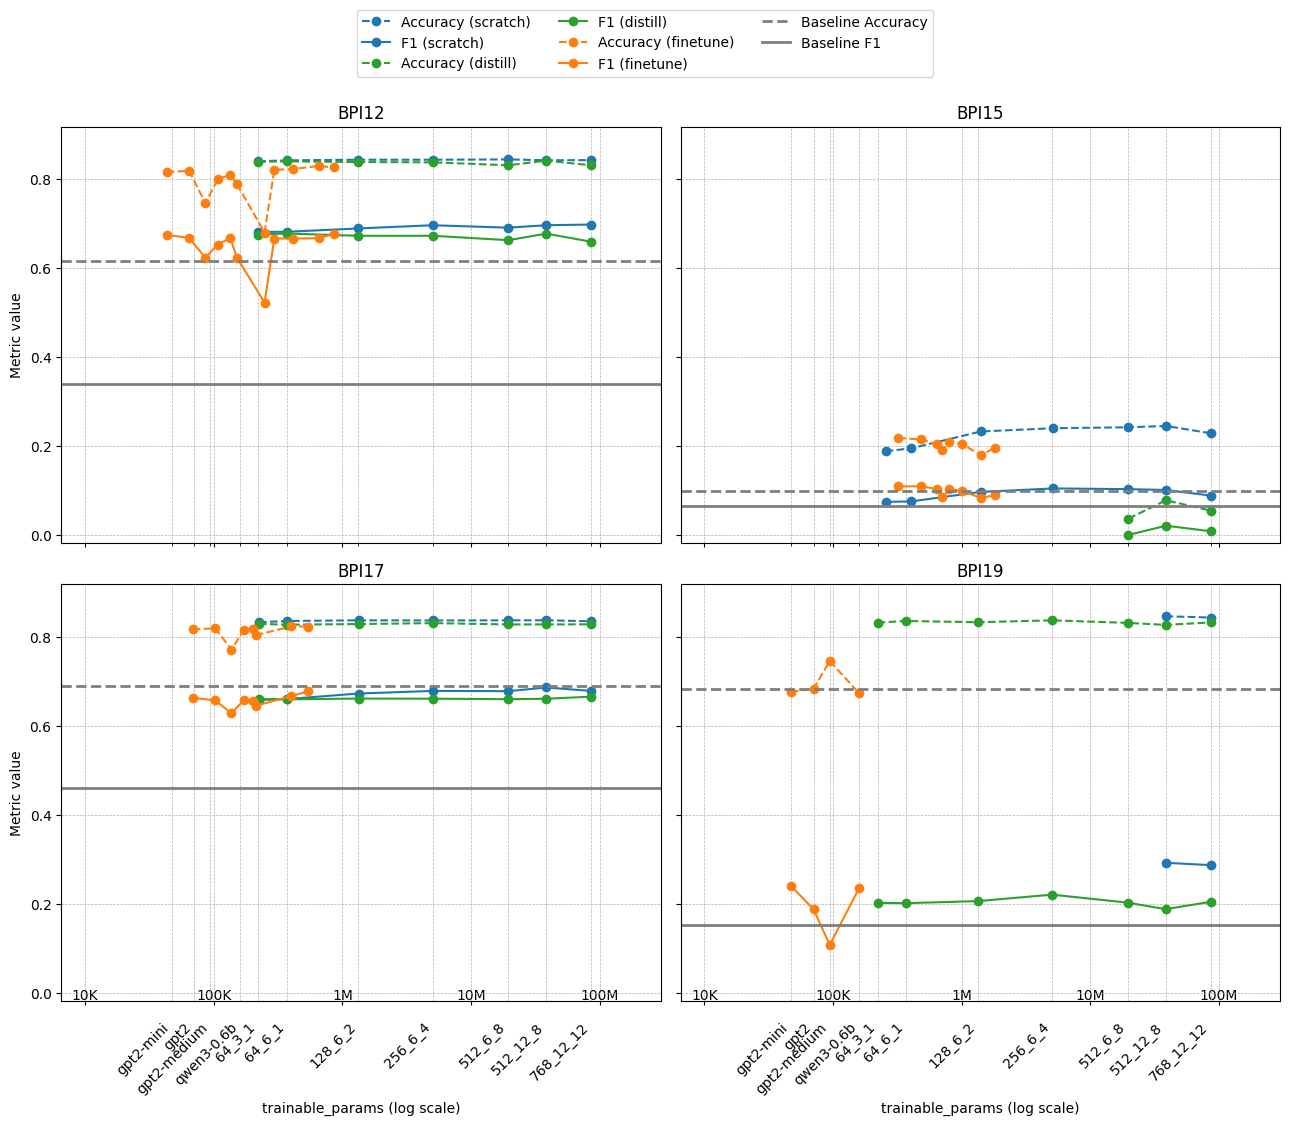

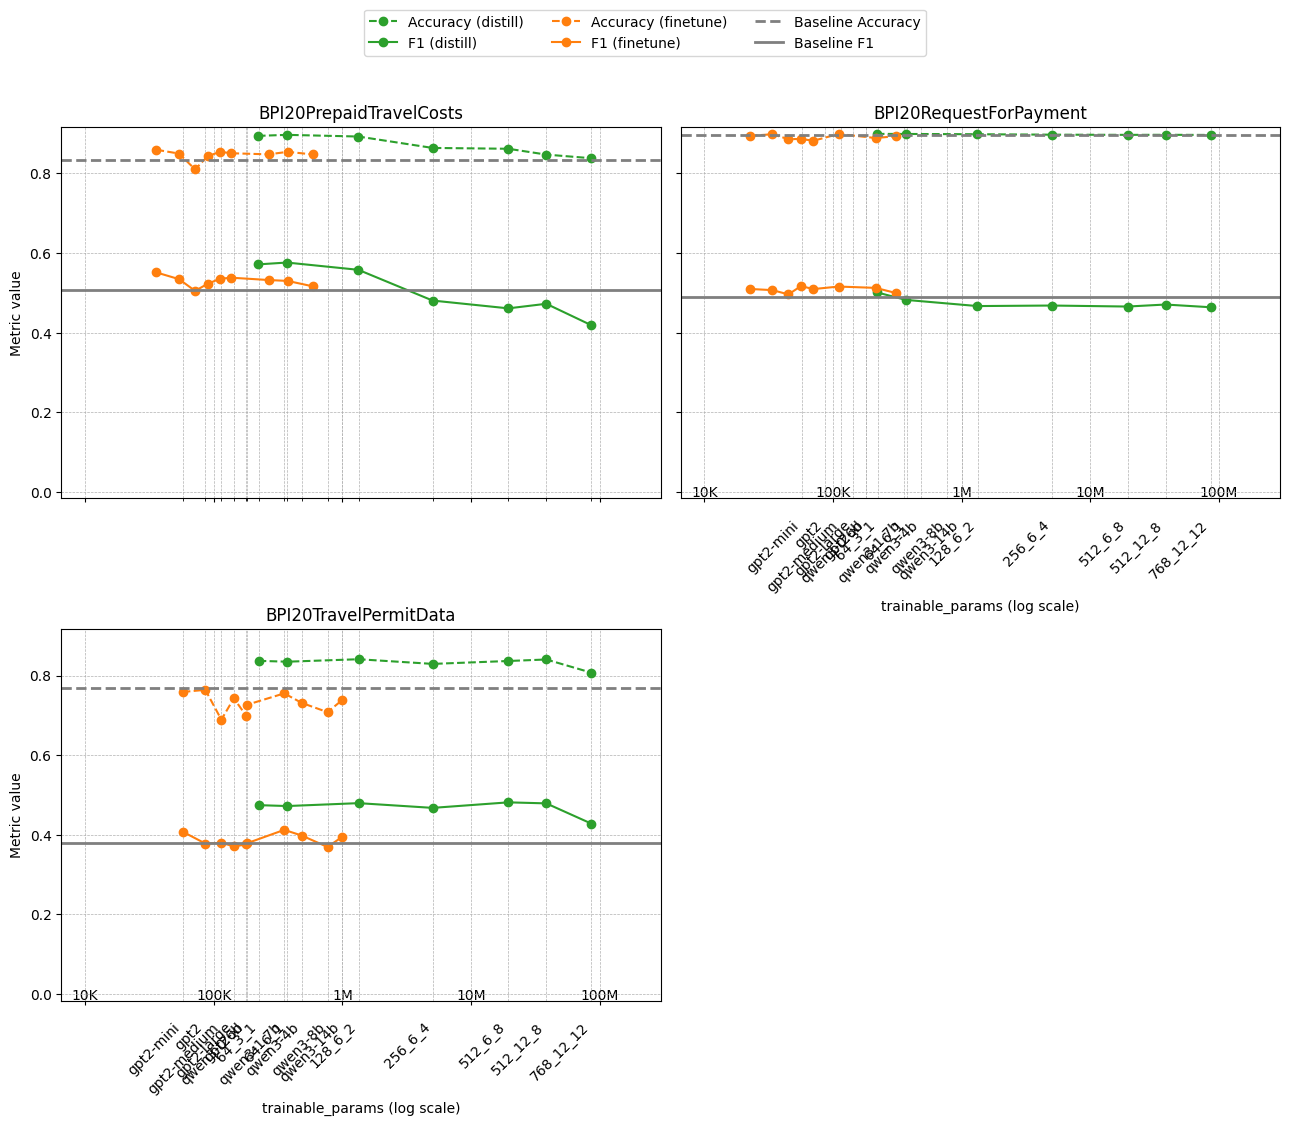

In [113]:
# ----------------------------
# 6) RUN IT
# ----------------------------
# Assumes you already have a DataFrame named `runs`.
summary = build_summary_with_std(runs)
best_per_log_backbone = select_best_lr_per_log_backbone(summary)

save_path = plots_dir / "all_logs_trainable_params.png"

plot_all_logs_matrix(
    best_per_log_backbone,
    x_axis="trainable_params",
    save_path=str(save_path),
)

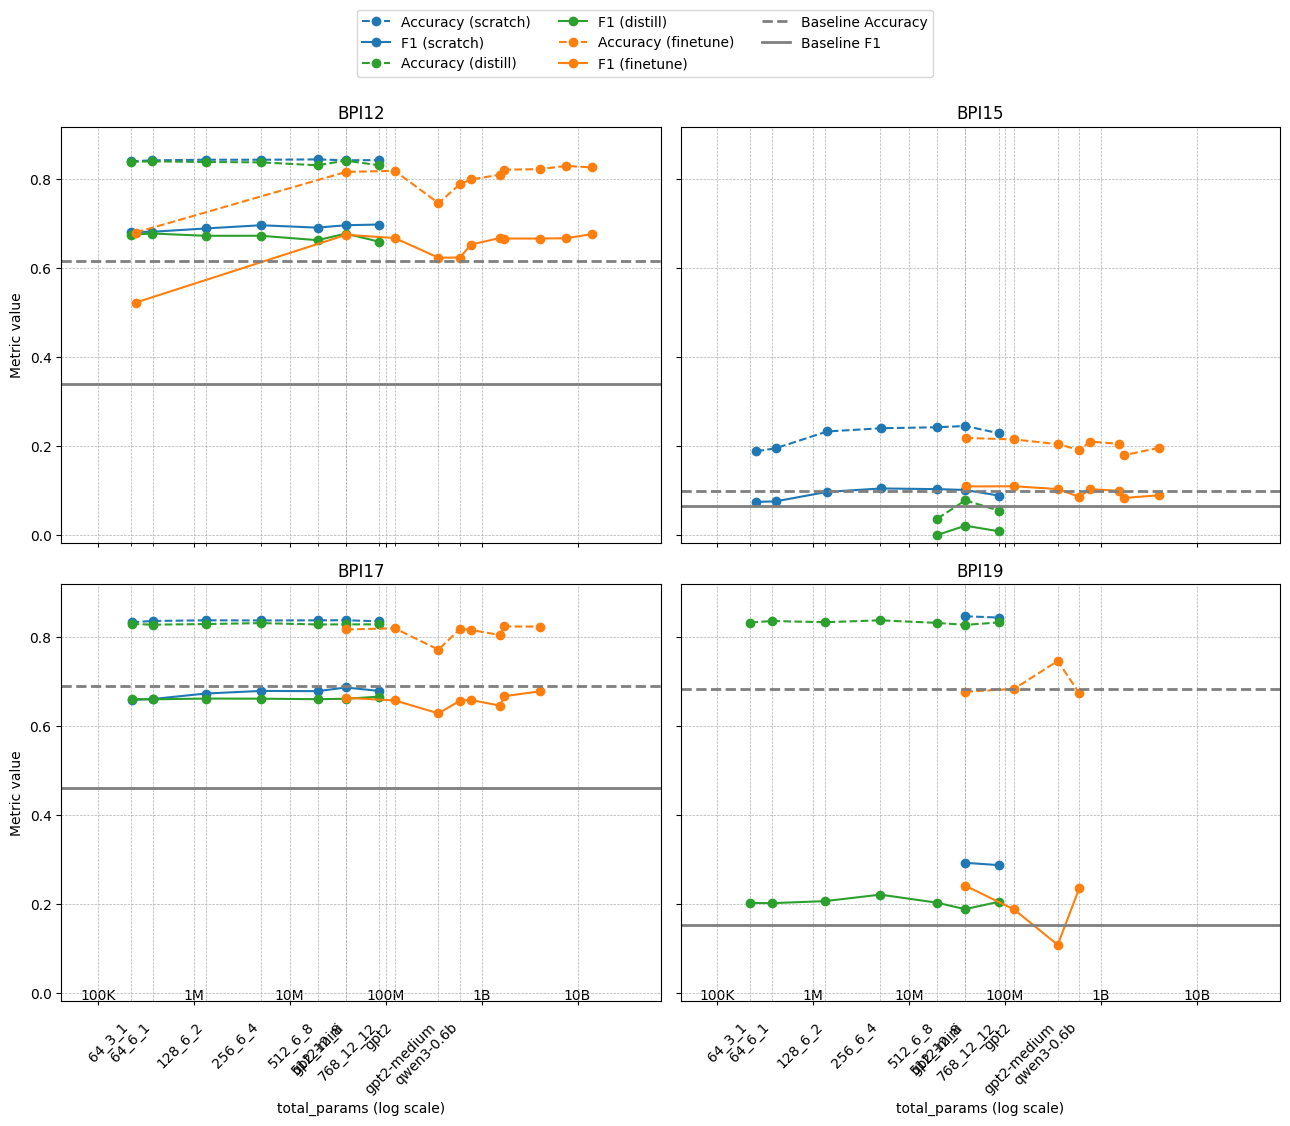

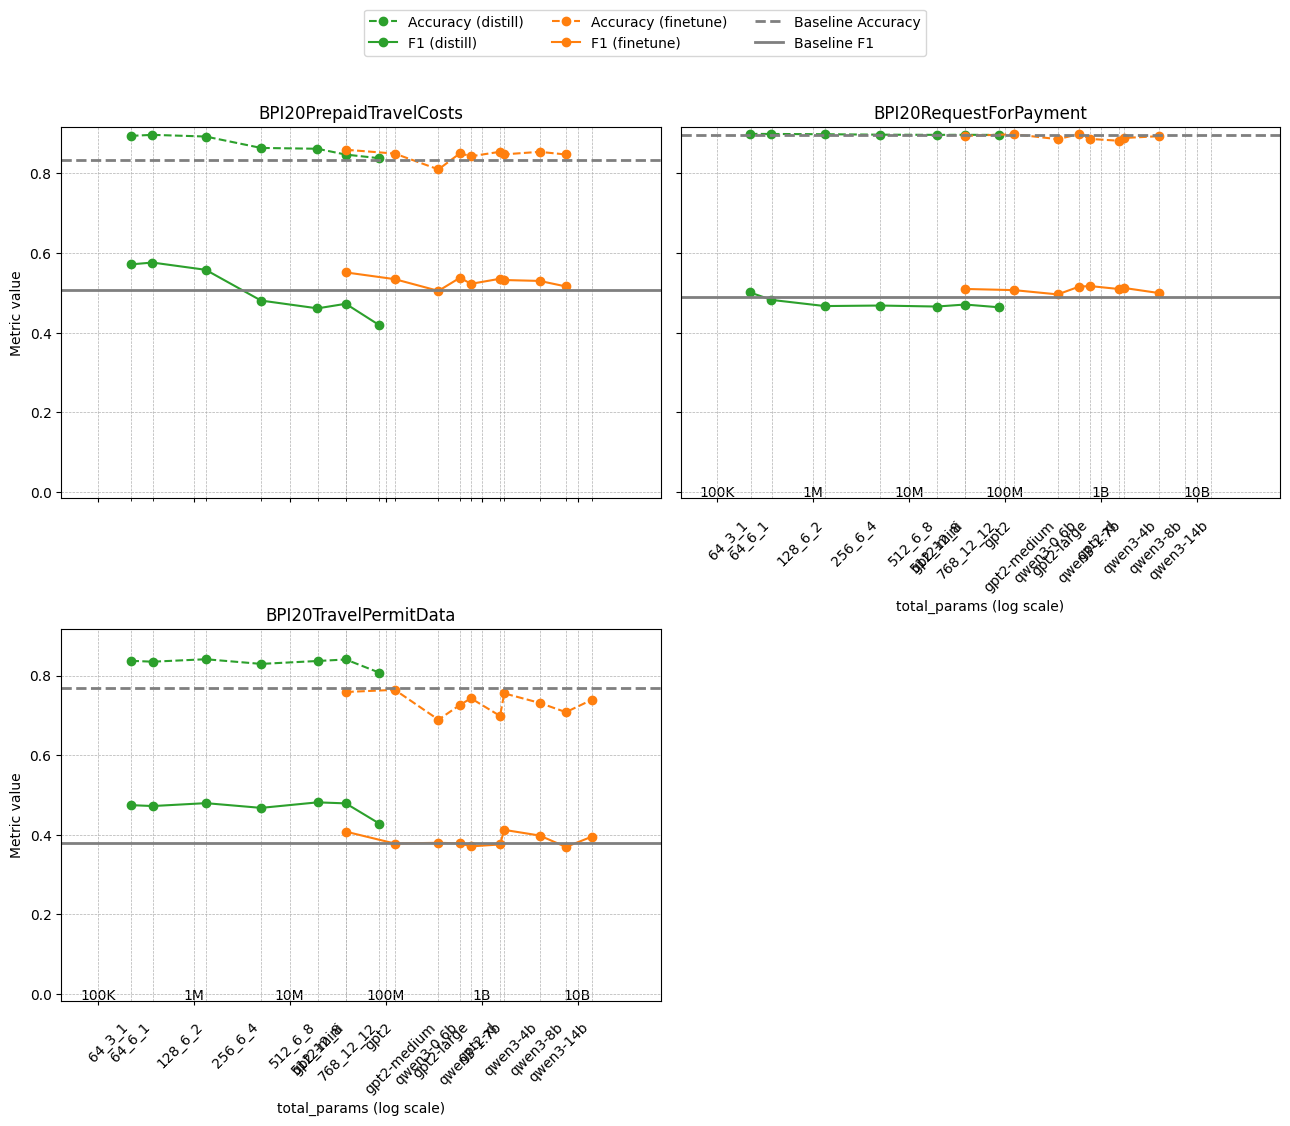

In [114]:
save_path = plots_dir / "all_logs_total_params.png"

plot_all_logs_matrix(
    best_per_log_backbone,
    x_axis="total_params",
    save_path=str(save_path),
)

In [106]:
runs.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'n_heads', 'backbone',
       ...
       'val_next_activity_CE_loss', 'val_next_activity_KL_loss',
       'val_next_activity_total_loss', 'best_test_final_next_activity_auroc',
       'test_next_activity_auroc', 'train_next_activity_auroc',
       'val_next_activity_auroc', 'seed', 'prediction_table',
       'transition_table'],
      dtype='str', length=120)